In [1]:
import matplotlib.pyplot as plt
from scipy.io import loadmat

cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
mpl.rc('xtick', labelsize=7)
mpl.rc('ytick', labelsize=7)
mpl.rc('axes', labelsize=6)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=6)
mpl.rc('axes', linewidth=0.5)
figsavepath = "../../Elements/MicroMirror"

C:\Users\TengMa\AppData\Local\Temp\ipykernel_42536\761535155.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("tab10")


In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
datadir = r'C:\Users\TengMa\OneDrive\POLIMI\1. MEMS SINDy\wetransfer_data_perseus_2025-05-16_1416\data_perseus'
positionname = 'sindy_perseus_S_FRF_IC0.mat'
velocityname = 'sindy_perseus_S_vel_FRF_IC0.mat'
datafile = "%s/%s"%(datadir, positionname)
P = "%s/%s"%(datadir, 'sindy_perseus_I_FRF_IC0.mat')
POM = "%s/%s"%(datadir, 'POM.mat')
import h5py
with h5py.File(datafile, 'r') as file:
    data = np.array(file['S'])
with h5py.File(P, 'r') as file:
    p = np.array(file['I'])


In [3]:
import importlib
import sys
sys.path.append("../")
import EvLOWN
importlib.reload(EvLOWN)  # 重新载入
library = [
    lambda x:x[0],
    lambda x:x[0]*x[0],
    lambda x:x[0]*x[0]*x[0],
    lambda x:x[1],
    lambda x:x[1]*x[1],
    lambda x:x[1]*x[1]*x[1],
    lambda x:x[2],
    lambda x:x[2]*x[2],
    lambda x:x[2]*x[2]*x[2],
    lambda x:x[3],
    lambda x:x[3]*x[3],
    lambda x:x[3]*x[3]*x[3],
    lambda x:x[4],
    lambda x:x[4]*x[4],
    lambda x:x[4]*x[4]*x[4],
    lambda x:x[5],
    lambda x:x[5]*x[5],
    lambda x:x[5]*x[5]*x[5],
]
library_name = [
    lambda x:x[0],
    lambda x:x[0]+x[0],
    lambda x:x[0]+x[0]+x[0],
    lambda x:x[0]+x[0]+x[0]+x[0],
    lambda x:x[0]+x[0]+x[0]+x[0]+x[0],
    lambda x:x[1],
    lambda x:x[1]+x[1],
    lambda x:x[1]+x[1]+x[1],
    lambda x:x[1]+x[1]+x[1]+x[1],
    lambda x:x[1]+x[1]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[1],
    lambda x:x[0]+x[0]+x[1],
    lambda x:x[0]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[1],
    lambda x:x[0]+x[0]+x[1]+x[1],
    lambda x:x[0]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[0]+x[1],
    lambda x:x[0]+x[0]+x[0]+x[1]+x[1],
    lambda x:x[0]+x[0]+x[1]+x[1]+x[1],
    lambda x:x[0]+x[1]+x[1]+x[1]+x[1],
]
dim = 3
model = EvLOWN.WeakNOForce(dim,library,library_name)

In [4]:
timestamp = 99999
timeeffect = 99999
Modes = 3
Modeshape = loadmat(POM)["POM"]
node = 4526
POM_1 = Modeshape[node,:3]
stp = 5
enp = 5
Effectidxs = [
    [0,2,3,18],
    [1,4],
    [1,4]
]
Omegaidxs = [0,6,12]
orders = [[1,2],[0,3,4],[0,3,4]]

In [5]:
from tqdm import tqdm
Xi_all = np.zeros([22,len(library)+1, Modes])
for num in tqdm(range(22)):
    
    start = num*timestamp+1
    end = (num+1)*timestamp
    F_omega1 = p[1,start]
    F_amplitude = p[2,start]
    # print(F_omega1, F_amplitude)
    
    t = p[0,start:start+timeeffect]
    F = np.cos(F_omega1*t)
    displacement = data[:Modes,start:start+timeeffect]
    velocity = np.zeros([Modes,timeeffect])
    for mode in range(Modes):
        velocity[mode] = np.gradient(data[mode,start:start+timeeffect],t)
    model.Get_frequency(displacement.T,velocity.T,t[:])
    # print(model.frequencys)
    model.frequencys[1] = model.frequencys[0]
    model.frequencys[2] = model.frequencys[0]
    model.Get_Evolution(order = [0,1,2])
    model.Library_rebuild(F[:])
    
    Xis = np.zeros([len(library)+1, Modes])
    for d in range(Modes):
        Xi = EvLOWN.Xi(
            model.dot[d][stp :-enp,orders[d]],
            model.Phi[d][stp :-enp,orders[d],:],
            Effectidxs[d])
        
        Xis[:,d] = Xi
        Xis[Omegaidxs[d],d] += model.frequencys[0]**2
    if num>=11:
        Xis[18,0] = Xis[18,0]/3
    Xi_all[num] = Xis

100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [13:21<00:00, 36.44s/it]


In [6]:
Xis[18,0]

0.0533695662328759

In [7]:
import pandas as pd
Labels = ['w1','c1','alpha11','beta1','w2','alpha21','alpha22','w3','alpha31','alpha32']
Idxs = [[0,0],[0,3],[0,2],[0,18],[1,6],[1,1],[1,4],[2,12],[2,1],[2,4]]
Coef = {}
for i in range(len(Labels)):
    Coef[Labels[i]] = []
for i in range(22):
    for j in range(len(Labels)):
        Coef[Labels[j]].append(Xi_all[i,Idxs[j][1],Idxs[j][0]])
Coef = pd.DataFrame(Coef)
Coef

,w1,c1,alpha11,beta1,w2,alpha21,alpha22,w3,alpha31,alpha32
0,0.033827,0.000184,-9.874069e-12,0.053470,0.033839,-1.398282e-07,0.000039,0.033839,-8.925229e-07,0.000024
1,0.033827,0.000184,-9.930604e-12,0.053405,0.033839,-1.395855e-07,0.000039,0.033839,-8.927578e-07,0.000024
2,0.033827,0.000184,-9.935780e-12,0.053427,0.033788,-1.400262e-07,0.000039,0.033788,-8.931485e-07,0.000024
3,0.033827,0.000184,-9.956905e-12,0.053443,0.033788,-1.371116e-07,0.000039,0.033788,-8.932153e-07,0.000024
4,0.033827,0.000184,-1.000478e-11,0.053379,0.033788,-1.356790e-07,0.000039,0.033788,-8.944246e-07,0.000024
5,0.033827,0.000184,-1.011168e-11,0.053443,0.033788,-1.351341e-07,0.000039,0.033788,-8.949554e-07,0.000024
6,0.033827,0.000185,-1.006242e-11,0.053491,0.033736,-1.353541e-07,0.000039,0.033736,-8.945512e-07,0.000024
7,0.033827,0.000184,-1.000934e-11,0.053377,0.033736,-1.367729e-07,0.000039,0.033736,-8.946463e-07,0.000024
8,0.033827,0.000184,-9.885671e-12,0.053392,0.033736,-1.362771e-07,0.000039,0.033736,-8.932255e-07,0.000024
9,0.033827,0.000184,-9.762632e-12,0.053484,0.033736,-1.364856e-07,0.000039,0.033736,-8.927136e-07,0.000024


In [8]:
Xi_all[0,0,0]

0.033826568235051174

In [14]:
t_pred = np.linspace(0,timeeffect,timeeffect*2)
stable_stamp = 5000
stable_orbit = np.zeros([22, stable_stamp, Modes])
from tqdm import tqdm
for num in tqdm(range(22)):
    start = num*timestamp+1
    F_omega1 = p[1,start]
    def ROM_Mirror(x,t):
        dxdt = np.zeros(len(x))
        for d in range(3):
            dxdt[d*2] = x[d*2+1]
            for i in range(len(library)):
                dxdt[d*2+1] -= library[i](x)*Xi_all[num,i,d]
            if num>=11:
                dxdt[d*2+1] -= np.cos(F_omega1*t)*Xi_all[num,-1,d]*3
            else:
                dxdt[d*2+1] -= np.cos(F_omega1*t)*Xi_all[num,-1,d]
        return dxdt
    x0 = [0,0,0,0,0,0]
    x = odeint(ROM_Mirror, x0, t_pred)
    stable_orbit[num,:,:] = x[-stable_stamp:,[0,2,4]]
    
    

100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [13:43<00:00, 37.41s/it]


In [40]:
radius = 900
node = 4526
# node = 950
omegas = np.zeros(22)
As = np.zeros(22)
for i in range(22):
    start = i*timestamp+1
    e2 = np.sum(stable_orbit[i,:,:]*Modeshape[node-1,:3], axis = 1)
    e3 = np.sum(stable_orbit[i,:,:]*Modeshape[node,:3], axis = 1)
    # theta = 2*np.degrees(np.arctan2(np.sqrt(e2**2+e3**2)/2,radius))
    theta = np.degrees(np.arctan2(e3,radius))
    As[i] = (np.max(theta) - np.min(theta))/2
    omegas[i] = p[1,start]

In [41]:
train_frf = {
    'freq': omegas,
    'frf': As
}
pd.DataFrame(train_frf).to_csv('../../Validation/Micromirror2/trainset.csv')

In [42]:
import pandas as pd
import scipy
Omegas_FOMs = []
response_FOMs = []
Omegas_ROMs = []
response_ROMs = []
betas = [1.0,1.5,2.0,2.5,3.0]
for i in range(len(betas)):
    file = "../../Validation/Micromirror2/beta%.1f-1.csv"%betas[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOMs.append(data_FOM[0])
    response_FOMs.append(data_FOM[1])
    # y = scipy.io.loadmat('../../Validation/Micromirror2/matcont_origin_3_%.2f-21.mat'%(betas[i]/2))
    # y = y['xlcc']
    # # print(POM_1)
    # freq, frf = xlcc2frf(y, Modeshape[node,:3])
    # Omegas_ROMs.append(freq[:-1])
    # response_ROMs.append(frf[:-1])

C:\Users\TengMa\AppData\Local\Temp\ipykernel_42536\497990179.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("Blues")


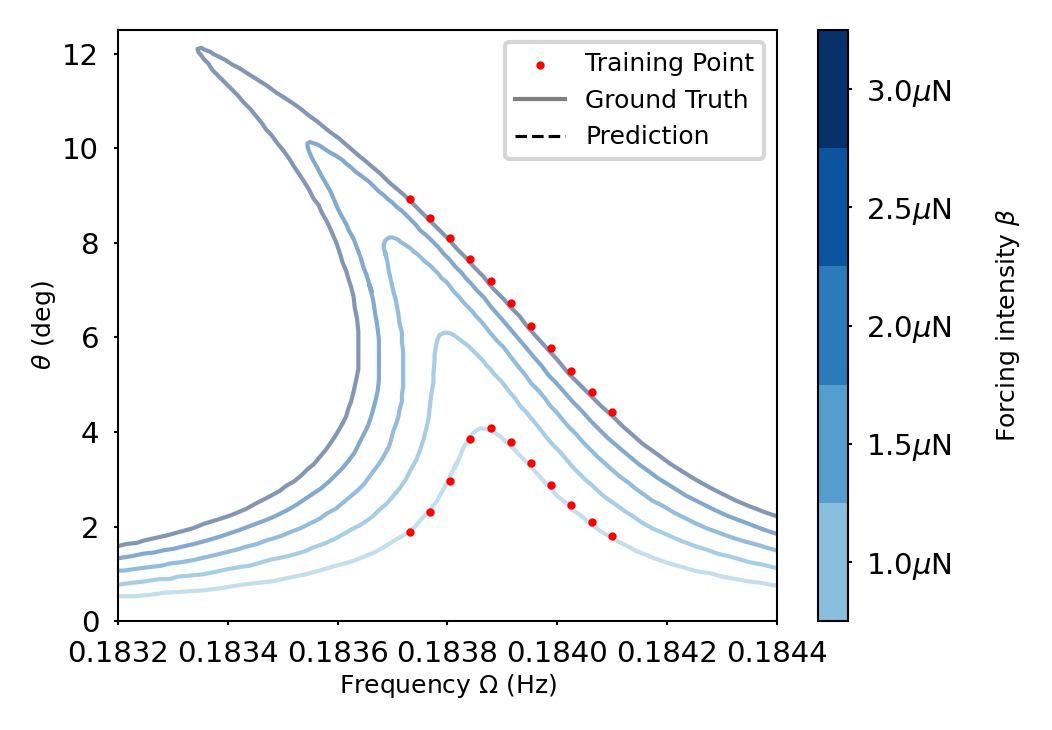

In [44]:
fig, ax = plt.subplots(figsize = (9/2.54, 6.5/2.54),dpi = 300)
cm_number = 8
cm = plt.cm.get_cmap("Blues")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]

for i in range(len(betas)):
    
    plt.plot(Omegas_FOMs[i], response_FOMs[i], color = colors[i+3],alpha = 0.5,lw = 1, ls = '-')
    # plt.plot(Omegas_ROMs[i], response_ROMs[i], lw = 0.75, ls = '--', color = colors[i+3])

ax.scatter(omegas,As, color = 'red', s = 1,zorder = 100,label = 'Training Point')
ax.plot([0,0],[1,1],ls = '-',alpha = 0.5,lw = 1,color = 'black',label = 'Ground Truth')
ax.plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = 'black',label = 'Prediction')
plt.legend(fontsize = 6)
# plt.scatter(Omegas_FOM, responses_FOM, s =9,marker = '*',label = 'FOM',zorder = 100)
ax.set_ylim(0,12.5)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlim(0.1832,0.1844)
ax.set_xlabel('Frequency $\Omega$ (Hz)')
ax.set_ylabel(r'$\theta$ (deg)')

cmap_discrete = mpl.colors.ListedColormap(colors[3:])
bounds = list(range(3, cm_number+1))
norm = mpl.colors.BoundaryNorm(bounds, cmap_discrete.N)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_discrete)
sm.set_array([])
tick_positions = [3.5, 4.5, 5.5, 6.5, 7.5]
# 你可以根据实际意义随意改 label 文本
tick_labels = ['1.0$\mu$N','1.5$\mu$N','2.0$\mu$N','2.5$\mu$N','3.0$\mu$N']  
ax.tick_params(direction='out',width = 0.5,length = 1)
cbar = fig.colorbar(sm, ax=ax, ticks=tick_positions)
cbar.ax.set_yticklabels(tick_labels)
cbar.set_label(r"Forcing intensity $\beta$",labelpad = 10)
cbar.ax.minorticks_off()
cbar.ax.tick_params(direction='out',width = 0.5,length = 1)

In [18]:
Mirror_file = """function out = oscill_2dof_1to2
 out{1} = @init;
 out{2} = @fun_eval; 
 out{3} = [];
 out{4} = [];
 out{5} = [];
 out{6} = [];
 out{7} = [];
 out{8} = [];
 out{9} = [];
 out{10}= @userf1;
end


function dydt = fun_eval(t,x,w)
u1=x(1);
v1=x(2);
u2=x(3);
v2=x(4);
u3=x(5);
v3=x(6);
sin=x(7);
cos=x(8);
A = %.3f;
coeff_prop = 1e3;
dydt = [
    v1;
    %.10e*u1 + %.10e*v1 + %.10e*u1^3*coeff_prop^2 + %.10e/0.5*A*cos/coeff_prop;
    v2;
    %.10e*u2 + %.10e*u1^2*coeff_prop + %.10e*v1^2*coeff_prop;
    v3;
    %.10e*u3 + %.10e*u1^2*coeff_prop + %.10e*v1^2*coeff_prop;
    +w*cos + sin - sin*(sin^2+cos^2);
    -w*sin + cos - cos*(sin^2+cos^2);
];

end
"""

In [19]:
filedir = './Mirrors/'
As = np.linspace(0.5,1.5,5)
for idx in range(22):
    for A in range(5):
        with open("%sMirror%d%d.m"%(filedir, A, idx),'w') as f:
            f.write(Mirror_file%(
                As[A],
                -Coef['w1'][idx],
                -Coef['c1'][idx],
                -Coef['alpha11'][idx],
                -Coef['beta1'][idx],
                -Coef['w2'][idx],
                -Coef['alpha21'][idx],
                -Coef['alpha22'][idx],
                -Coef['w3'][idx],
                -Coef['alpha31'][idx],
                -Coef['alpha32'][idx]
            ))

In [181]:
print(Modes)
Xis = np.zeros([len(library)+1,Modes])
# fig, axes = plt.subplots(Modes,2,figsize = (4,Modes*0.5),dpi = 200)
# plt.subplots_adjust(hspace = 0, wspace = 0.15)
displacement = data[:Modes,start:start+timeeffect]
velocity = np.zeros([Modes,timeeffect])
for mode in range(Modes):
    velocity[mode] = np.gradient(data[mode,start:start+timeeffect],t)
# velocity = np.gradient(data[:Modes,start:start+timeeffect],t,axis = 0)
model.Get_frequency(displacement.T,velocity.T,t[:])
print(model.frequencys)
model.frequencys[1] = model.frequencys[0]
model.frequencys[2] = model.frequencys[0]
model.Get_Evolution(order = [0,1,2])
model.Library_rebuild(F[:])
T_period = 2*np.pi/model.frequencys[0]
num_period = int((t[-1] - t[0]) // T_period)
t_periods = np.linspace(0,t[-1], num_period+1)
Fs = timeeffect/(t[-1]-t[0])
print(Fs)

3
[0.18353387 0.         0.36720805]
2.92713582850767


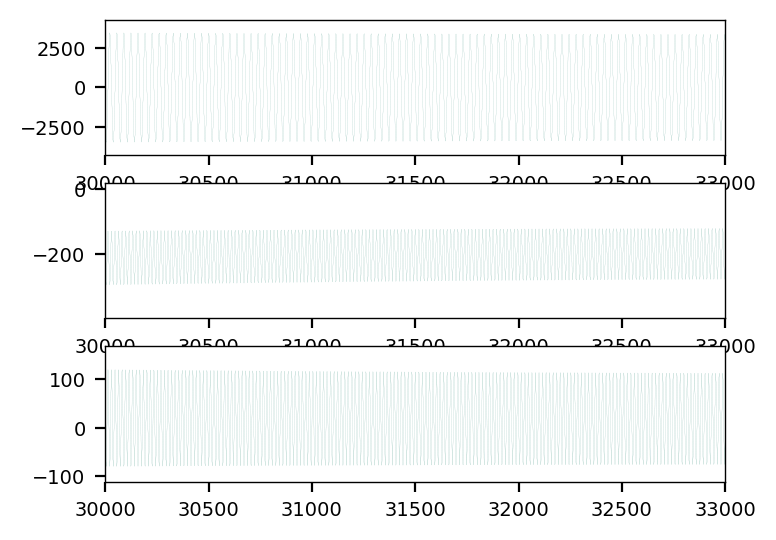

In [182]:
Modes = 3


slow_variables = np.zeros([Modes,len(t),5])
for d in range(Modes):
    for j in range(5):
        for i in range(num_period):
            slow_variables[d,int(T_period*i*Fs):int((T_period*(i+1))*Fs),j] = model.evolutions[d][i,j]
fig, axes = plt.subplots(Modes,1,figsize = (4,Modes*1),dpi = 200)
bases = [np.ones_like(t),np.cos(model.frequencys[0]*t),np.sin(model.frequencys[0]*t),np.cos(2*model.frequencys[0]*t),np.sin(2*model.frequencys[0]*t)]
for d in range(Modes):
# d = 2
    ax = axes[d]
    ax.plot(t,displacement[d], lw = 0.02)
    approx = np.zeros_like(t)
    for j in orders[d]:
        approx+=bases[j]*slow_variables[d,:,j]
    ax.plot(t,approx,lw = 0.02, ls = '--',color = 'green')
    # ax.plot(t,approx - x[:,d*2],lw = 0.2, ls = '--',color = 'green')
    # ax.set_xlim(0,t[-1])
    ax.set_xlim(30000,33000)

[[ 3.38354425e-02  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -1.01246100e-07 -9.19767388e-07]
 [-1.22981447e-11  0.00000000e+00  0.00000000e+00]
 [ 1.85517357e-04  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  3.93354940e-05  2.37270327e-05]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  3.36846809e-02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  3.36846809e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.60108699e-01  0.00000000e+00  0.00000000e+00]]


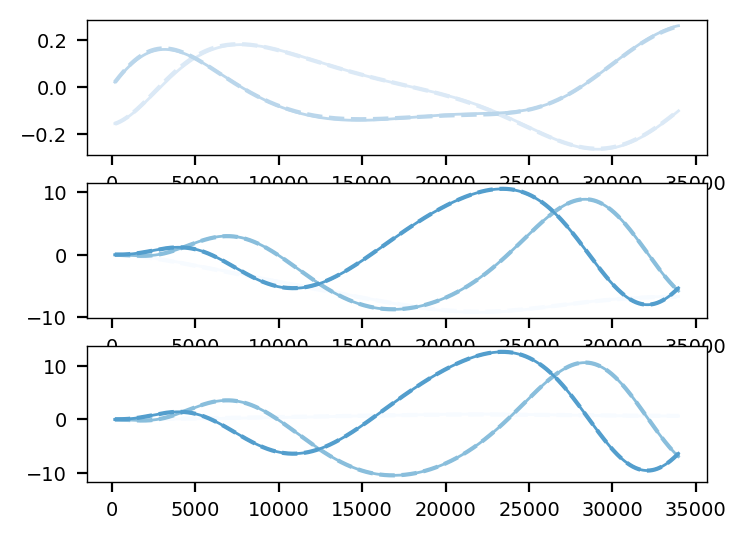

In [183]:
d = 1
stp = 5
enp = 5
Effectidxs = [
    [0,2,3,18],
    [1,4],
    [1,4]
]
Omegaidxs = [0,6,12]
Xis = np.zeros([len(library)+1, Modes])
fig, axes = plt.subplots(Modes,1,figsize = (4,Modes*1),dpi = 200)
for d in range(Modes):
    Xi = EvLOWN.Xi(
        model.dot[d][stp :-enp,orders[d]],
        model.Phi[d][stp :-enp,orders[d],:],
        Effectidxs[d])
    
    Xis[:,d] = Xi
    Xis[Omegaidxs[d],d] += model.frequencys[0]**2
    # for d in range(3):
    #     ax = axes[d]
    ax = axes[d]
    for i in orders[d]:
        ax.plot(t_periods[stp:-enp-1],model.dot[d][stp:-enp,i],color = colors[i],lw = 1)
        ax.plot(t_periods[stp:-enp-1],np.sum(model.Phi[d][stp:-enp,i,:]*Xi, axis = 1),color = colors[i],ls = '--',lw = 1.5)
print(Xis)

In [287]:
def ROM_Mirror(x,t):
    dxdt = np.zeros(len(x))
    for d in range(3):
        dxdt[d*2] = x[d*2+1]
        for i in range(len(library)):
            dxdt[d*2+1] -= library[i](x)*Xis[i,d]
        dxdt[d*2+1] -= np.cos(F_omega1*t)*Xis[-1,d]
    return dxdt

t_pred = np.linspace(0,timeeffect,timeeffect*2)
x0 = [0,0,0,0,0,0]
x = odeint(ROM_Mirror, x0, t_pred)


8.953890476839595


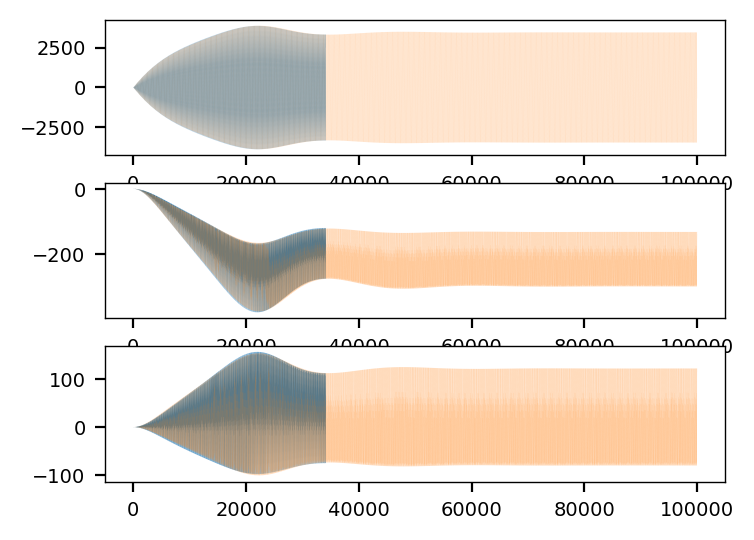

In [320]:
orbit = np.sum(x[2*timeeffect-5000:2*timeeffect,[0,2,4]] * Modeshape[node,:3], axis = 1)
Train_FRF = np.max(np.degrees(np.arcsin(np.abs(orbit)/1010)))
print(Train_FRF)
fig, axes = plt.subplots(Modes,1,figsize = (4,Modes*1),dpi = 200)
for i in range(Modes):
    ax = axes[i]
    ax.plot(t, data[i, start:start+timeeffect], lw = 0.02)
    ax.plot(t_pred, x[:,i*2],lw = 0.01, ls = '--')
    # ax.set_xlim(0,t[-1])
    # ax.set_xlim(32000,33000)

In [333]:
def xlcc2frf(xlcc,POMs):
    d1, d2 = np.shape(xlcc)
    num = len(POMs)
    orbit_len = (d1-2-2-num*2)//(num*2+2)
    frfs = np.zeros(d2)
    for j in range(d2):
        orbits = np.zeros([orbit_len,num])
        for i in range(num):
            orbits[:,i] = xlcc[i*2:-((num+1)*2)-2+i*2:(num+1)*2, j]
        orbit_poms = np.sum(orbits * POMs, axis = 1)
        frfs[j] =  np.degrees(np.arcsin((np.max(orbit_poms) - np.min(orbit_poms))/2/975))
    return xlcc[-1,:], frfs

In [20]:
import pandas as pd
Omegas_FOMs = []
response_FOMs = []
Omegas_ROMs = []
response_ROMs = []
betas = [1.0,1.5,2.0,2.5,3.0]
for i in range(len(betas)):
    file = "../../Validation/Micromirror2/beta%.1f-1.csv"%betas[i]
    data_FOM = pd.read_csv(file, header = None)
    Omegas_FOMs.append(data_FOM[0])
    response_FOMs.append(data_FOM[1])
    y = scipy.io.loadmat('../../Validation/Micromirror2/matcont_origin_3_%.2f-21.mat'%(betas[i]/2))
    y = y['xlcc']
    # print(POM_1)
    freq, frf = xlcc2frf(y, Modeshape[node,:3])
    Omegas_ROMs.append(freq[:-1])
    response_ROMs.append(frf[:-1])

NameError: name 'scipy' is not defined

In [ ]:
fig, ax = plt.subplots(figsize = (9/2.54, 6.5/2.54),dpi = 300)
cm_number = 8
cm = plt.cm.get_cmap("Blues")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
length = 1000
l_idx = [0,51,56,61,65]
r_idx = [0,51,59,65,70]
for i in range(len(betas)):
    
    plt.plot(Omegas_FOMs[i], response_FOMs[i], color = colors[i+3],alpha = 0.5,lw = 1, ls = '-')
    plt.plot(Omegas_ROMs[i], response_ROMs[i], lw = 0.75, ls = '--', color = colors[i+3])
# plt.plot(Omegas_ROM, np.degrees(np.arcsin(response_ROM[0,:]/length)),lw = 0.75, ls = '--', color = colors[i+3])
    # if i<1:
    #     plt.plot(Omegas_ROM, np.degrees(np.arcsin(response_ROM[i,:]/length)),lw = 0.75, ls = '--', color = colors[i+3])
    # else:
    #     plt.plot(Omegas_ROM[:l_idx[i]], np.degrees(np.arcsin(response_ROM[i,:l_idx[i]]/length)),lw = 0.75, ls = '--', color = colors[i+3])
    #     plt.plot(Omegas_ROM[r_idx[i]:], np.degrees(np.arcsin(response_ROM[i,r_idx[i]:]/length)),lw = 0.75, ls = '--', color = colors[i+3])
# plt.plot(freq[:-5],frf[:-5])
ax.scatter([Train_FREQ],[Train_FRF], color = 'red', s = 4,zorder = 100,label = 'Training Point')
ax.plot([0,0],[1,1],ls = '-',alpha = 0.5,lw = 1,color = 'black',label = 'Ground Truth')
ax.plot([0,0],[1,1],ls = '--',alpha = 1,lw = 0.75,color = 'black',label = 'Prediction')
plt.legend(fontsize = 6)
# plt.scatter(Omegas_FOM, responses_FOM, s =9,marker = '*',label = 'FOM',zorder = 100)
ax.set_ylim(0,12.5)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlim(0.1832,0.1844)
ax.set_xlabel('Frequency $\Omega$ (Hz)')
ax.set_ylabel(r'$\theta$ (deg)')

cmap_discrete = mpl.colors.ListedColormap(colors[3:])
bounds = list(range(3, cm_number+1))
norm = mpl.colors.BoundaryNorm(bounds, cmap_discrete.N)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_discrete)
sm.set_array([])
tick_positions = [3.5, 4.5, 5.5, 6.5, 7.5]
# 你可以根据实际意义随意改 label 文本
tick_labels = ['1.0$\mu$N','1.5$\mu$N','2.0$\mu$N','2.5$\mu$N','3.0$\mu$N']  
ax.tick_params(direction='out',width = 0.5,length = 1)
cbar = fig.colorbar(sm, ax=ax, ticks=tick_positions)
cbar.ax.set_yticklabels(tick_labels)
cbar.set_label(r"Forcing intensity $\beta$",labelpad = 10)
cbar.ax.minorticks_off()
cbar.ax.tick_params(direction='out',width = 0.5,length = 1)

[0.18367418]
0.9758054695962848
0.024194530403715196
0.9758112097864251
-5.740190140273309e-06
0.9750495121937758
0.0007616975926493494
0.9750493330475137
1.7914626195144863e-07
0.9901877514788304
-0.015138418431316634
[0.00000000e+00 1.00000175e+00 0.00000000e+00 8.32577907e-05
 2.36553858e+00 6.82214800e-01 4.00217417e+00 0.00000000e+00
 0.00000000e+00]
[0.18367418]
0.9995650045704241
0.00043499542957594933
0.9006537733623936
0.09891123120803043
0.4576696806349174
0.4429840927274762
0.0007108356241231632
0.4569588450107943
0.0005218410054994944
0.00018899461862366887
0.00042788534699717126
9.395565850232318e-05
0.0004253673883262747
2.5179586708965493e-06
0.0004246295970341935
7.37791292081199e-07
0.0004246331718891829
-3.5748549894064346e-09


LinAlgError: Singular matrix

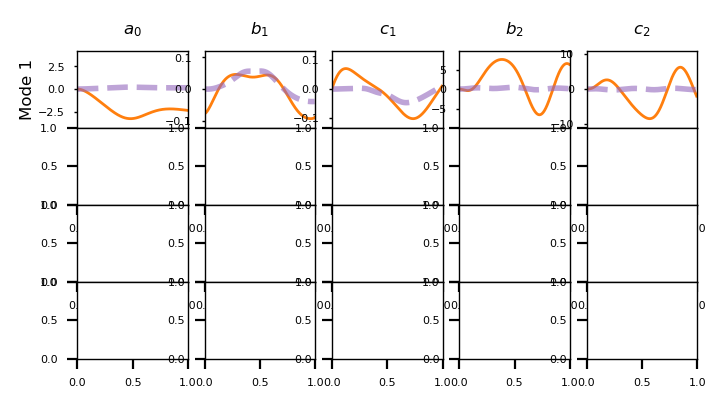

In [95]:
from scipy.interpolate import interp1d
# mode = 2
stp = 5
enp = 5
Xis = np.zeros([len(library)+1,Modes])
model = EvLOWN.WeakNOForce(dim,library,library_name)
Phis = np.zeros([Modes,len(t_periods[stp:-enp]),5,len(library)+1])
dots = np.zeros([Modes,len(t_periods[stp:-enp]),5])
freqs = np.zeros([Modes])
fig, axes = plt.subplots(Modes,5,figsize = (4,Modes*0.5),dpi = 200)
plt.subplots_adjust(hspace = 0, wspace = 0.15)
for mode in range(Modes):
    velocity = np.gradient(Aft_transform[mode],t[1] - t[0])
    model.Get_frequency(Aft_transform[mode][:].reshape(-1,1),velocity[:].reshape(-1,1),t[:])
    print(model.frequencys)
    model.Get_Evolution(order = [0,1,2])
    model.Library_rebuild(F[:])
    model.Library_reschudle()
    T_period = 2*np.pi/model.frequencys[0]
    num_period = int((t[-1] - t[0]) // T_period)
    t_periods = np.linspace(0,t[-1], num_period+1)
    # Xi = Xi_test(model.dot[0][stp :-enp,:],model.Phi[0][stp :-enp,:,:],[0,2,3,9],Lambda = 1)
    model.optimize(
        w_A2b=1,
        startcycle=stp,
        endcycle=enp,
        sparse_threshold=1e-1,
        stop_tolerance=1e-5,
        step_tolerance=-1e-5,
        sparse_max=10,
        fixed = []
    )
    Xis[:,mode] = model.Xi[0]
    
    for j in range(model.harmonic_number):
        ax = axes[mode][j]
        y = model.dot[0][stp:-enp,j]
        if mode == Modes -1:
            
            ax.plot(t_periods[stp:-enp-1],y,label = "Ground Truth", color = colors[1], lw = 1)
            ax.plot(t_periods[stp:-enp-1],np.sum(model.Xi[0]*model.Phi[0][stp:-enp,j,:],axis = 1),color = colors[4],alpha = 0.6,lw = 2,ls = '--', label = "EvLOWN inference")
            if j==0:
                ax.legend(fontsize = 6, bbox_to_anchor = (4.5,5.2))
        else:
            ax.set_xticks([])
            ax.plot(t_periods[stp:-enp-1],y, color = colors[1], lw = 1)
            ax.plot(t_periods[stp:-enp-1],np.sum(model.Xi[0]*model.Phi[0][stp:-enp,j,:],axis = 1),color = colors[4],alpha = 0.6,lw = 2,ls = '--')
        if j == 0:
            ax.set_ylabel("Mode %d"%(mode+1),fontsize = 6)
        if mode == 0:
            axes[mode][0].set_title("$a_0$")
            axes[mode][1].set_title("$b_1$")
            axes[mode][2].set_title("$c_1$")
            axes[mode][3].set_title("$b_2$")
            axes[mode][4].set_title("$c_2$")
        
        # ax.plot(t_periods[stp:-enp-1],y,label = "Ground Truth", color = colors[1], lw = 1)
        ax.set_xlim(0,t[-1])
        ax.tick_params(direction='out',width = 0.5,length = 1)
        ax.set_ylim(-np.max(np.abs(y))*1.3,np.max(np.abs(y))*1.3)
        Xis[0,mode] += model.frequencys[0]**2

        # ax.legend()
# plt.savefig("../../Elements/MicroBeam/SlowEvolutionFitting.svg",dpi = 300,transparent = True,bbox_inches="tight")

In [96]:
print(Xis)

[[ 1.68681031e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.40258468e-07  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 3.93490965e-07  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-6.48738720e-06  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-4.08968545e-08  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]]


In [35]:
# fig, axes = plt.subplots(Modes,5,figsize = (4,Modes*0.5),dpi = 200)
for mode in range(Modes):
    for j in range(model.harmonic_number):
        ax = axes[mode][j]
        y = model.dot[0][stp:-enp,j]
        if mode == Modes -1:
            
            ax.plot(t_periods[stp:-enp-1],dots[mode,:,j],label = "Ground Truth", color = colors[1], lw = 1)
            ax.plot(t_periods[stp:-enp-1],np.sum(Xis[:,mode]*Phis[mode,:,j,:],axis = 1),color = colors[4],alpha = 0.6,lw = 2,ls = '--', label = "EvLOWN inference")
            if j==0:
                ax.legend(fontsize = 6, bbox_to_anchor = (4,6.0))
        else:
            ax.set_xticks([])
            ax.plot(t_periods[stp:-enp-1],dots[mode,:,j], color = colors[1], lw = 1)
            ax.plot(t_periods[stp:-enp-1],np.sum(Xis[:,mode]*Phis[mode,:,j,:],axis = 1),color = colors[4],alpha = 0.6,lw = 2,ls = '--')
        if j == 0:
            ax.set_ylabel("Mode %d"%(mode+1),fontsize = 6)
        if mode == 0:
            axes[mode][0].set_title("$a_0$")
            axes[mode][1].set_title("$b_1$")
            axes[mode][2].set_title("$c_1$")
            axes[mode][3].set_title("$b_2$")
            axes[mode][4].set_title("$c_2$")
        
        # ax.plot(t_periods[stp:-enp-1],y,label = "Ground Truth", color = colors[1], lw = 1)
        ax.set_xlim(-10,t[-1]+10)
        ax.tick_params(direction='out',width = 0.5,length = 1)
        ax.set_ylim(-np.max(np.abs(dots[:,:,j]))*1.3,np.max(np.abs(dots[:,:,j]))*1.3)
plt.savefig("%s/SlowEvolutionFitting.svg"%figsavepath,dpi = 300,transparent = True,bbox_inches="tight")

NameError: name 'dots' is not defined

$\ddot{x}+\omega^2x+c\dot{x}+\alpha_1 x^2+\alpha_2 x^3+\alpha_3 \dot{x}^2=Fcos(\Omega t)$

In [90]:
from copy import deepcopy
Xi_table = deepcopy(Xis)
for i in range(Modes):
    Xi_table[0,i] += freqs[i]**2
table_paras = {
    "$\omega$": np.sqrt(Xi_table[0,:]),
    "$c$": Xi_table[5,:],
    r"$\alpha_1$": Xi_table[1,:],
    r"$\alpha_2$": Xi_table[2,:],
    r"$\alpha_3$": Xi_table[6,:],
    "$F$": Xi_table[20,:]
}
idx = []
for i in range(Modes):
    idx.append("Mode %d"%(i+1))
import pandas as pd

pd.set_option('display.float_format', lambda x: '%.6e' % x)
a = pd.DataFrame(table_paras, index = idx)
a

,$\omega$,$c$,$\alpha_1$,$\alpha_2$,$\alpha_3$,$F$
Mode 1,1.839329e-01,1.986220e-04,-2.047328e-06,4.023168e-11,1.274758e-04,8.321911e-02
Mode 2,1.839371e-01,1.681918e-04,-1.526838e-06,8.892242e-11,-2.802258e-05,7.741025e-02
Mode 3,1.839004e-01,1.943797e-04,1.558160e-06,1.124876e-10,2.950609e-05,8.111332e-02
Mode 4,1.839198e-01,1.667450e-04,2.067358e-06,5.220552e-11,-1.256180e-04,7.474825e-02


In [61]:
def ROM(x,t, omega,A_F):
    u1, v1, u2, v2, u3, v3, u4, v4 = x
    dv1 = -1.839423e-01**2	*u1 + 2.038503e-06	*u1**2 - 3.756942e-11*u1**3 - 2.027974e-04*v1 - 1.271243e-04*v1**2 - 8.958187e-02/1.5*A_F*np.cos(omega*t)
    dv2 = -1.839351e-01**2	*u2 + 1.562781e-06*u2**2 - 9.452131e-11*u2**3 - 1.643286e-04*v2 + 2.861995e-05*v2**2 - 7.549999e-02/1.5*A_F*np.cos(omega*t)
    dv3 = -1.838850e-01**2 *u3 - 1.596755e-06	*u3**2 - 1.174480e-10*u2**3 - 2.069170e-04*v3 - 3.012409e-05*v3**2 - 8.765379e-02/1.5*A_F*np.cos(omega*t)
    dv4 = -1.839044e-01**2	*u4 - 2.061617e-06*u4**2 - 5.034116e-11*u4**3 - 1.815047e-04*v4 + 1.253700e-04*v4**2 - 	7.588136e-02/1.5*A_F*np.cos(omega*t)
    return [v1,dv1,v2,dv2,v3,dv3,v4,dv4]

In [62]:
POM = "%s/%s"%(datadir, 'POM.mat')
import h5py
import scipy
Modeshape = scipy.io.loadmat(POM)["POM"]

In [64]:

num = int(len(p[2,:])/timestamp)
Omegas_FOM = np.zeros(num)
Amplitudes_FOM = np.zeros(num)
responses_FOM = np.zeros(num)

    

transformation_matrix = 1/np.sqrt(4)*np.array([[1,1,1,1],[1,-1,1,-1],[1,1,-1,-1],[1,-1,-1,1]])
POM_1 = np.zeros(4)
for i in range(4):
    # print(f[node,i])
    POM_1[i] = Modeshape[node,i]
rotation_matrix = np.dot(POM_1,transformation_matrix.T)
print(rotation_matrix)
# print(Amplitudes_FOM)

[-0.00275492 -0.02829377  0.00880975 -0.01281896]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [65]:
stablestamp = 12500
for i in range(num):
    start = i*timestamp+1
    end = (i+1)*timestamp
    GT = data[0,start:end]
    Omegas_FOM[i] = p[1,start]
    Amplitudes_FOM[i] = p[2,start]
    orbit_FOM = np.dot(Modeshape[node,:],data[:,start+timeeffect-stablestamp:start+timeeffect])
    responses_FOM[i] = (np.max(orbit_FOM) - np.min(orbit_FOM))/2

In [68]:
from tqdm import tqdm
Omegas_ROM = np.linspace(0.1832,0.1844,100)
Afs_ROM = [0.5,1.5]
orbit_ROM = np.zeros([2,len(Omegas_ROM),stablestamp,Modes])
x0 = [0,0,0,0,0,0,0,0]
t = np.linspace(0,33333,timeeffect)
for i in tqdm(range(len(Omegas_ROM))):
    for j in range(len(Afs_ROM)):
        omega = Omegas_ROM[i]
        AF = Afs_ROM[j]
        sol = odeint(ROM, x0, t, args=(omega,AF))
        Stable_orbit = sol[-stablestamp:,[0,2,4,6]]
        orbit_ROM[j,i,:,:] = Stable_orbit
        

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [05:51<00:00,  3.51s/it]


In [70]:
response_ROM = np.zeros([2,len(Omegas_ROM)])
for i in tqdm(range(len(Omegas_ROM))):
    for j in range(len(Afs_ROM)):
        rotation_orbit = np.dot(rotation_matrix, orbit_ROM[j,i,:,:].T)
        response_ROM[j,i] = (np.max(rotation_orbit) - np.min(rotation_orbit))/2

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 12230.79it/s]


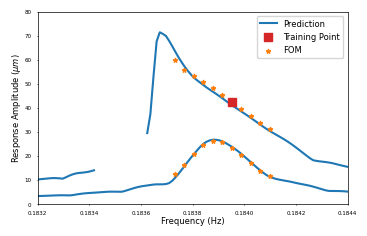

In [93]:
fig, ax = plt.subplots(figsize = (4,2.5))

for i in range(2):
    if i==0:
        plt.plot(Omegas_ROM, response_ROM[i,:,],color = colors[0],lw = 1.5,label = 'Prediction')
    else:
        plt.plot(Omegas_ROM[:19], response_ROM[i,:19,],color = colors[0],lw = 1.5)
        plt.plot(Omegas_ROM[35:], response_ROM[i,35:,],color = colors[0],lw = 1.5)
plt.scatter(Omegas_FOM[15],responses_FOM[15], s =40,color = colors[3],marker = 's',label = 'Training Point',zorder = 200)
plt.scatter(Omegas_FOM, responses_FOM, s =9,color = colors[1],marker = '*',label = 'FOM',zorder = 100)
ax.set_ylim(0,80)
ax.set_xlim(0.1832,0.1844)
ax.tick_params(direction='out',width = 0.5,length = 1)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Response Amplitude ($\mu m$)")
plt.legend(fontsize = 6)
plt.savefig("%s/FRCPrediction.svg"%figsavepath,dpi = 300,transparent = True,bbox_inches="tight")

In [91]:
Modeshape.shape

(9732, 64)

In [92]:
9732/3

3244.0